# Reporting IA - version simplifiée

- Génération de 500 lignes (seniors uniquement)
- Visualisation rapide
- KPI prestations
- Modèle de classification
- Export du modèle

In [23]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
import joblib

sns.set_theme(style="whitegrid")
np.random.seed(42)

base_path = Path.cwd()
out_dir = base_path / "ia_output"
if not out_dir.exists():
    out_dir = Path("..") / "ia_output"
out_dir.mkdir(parents=True, exist_ok=True)

dataset_path = out_dir / "dataset_module1_ia.csv"

cities = ["Paris", "Lyon", "Marseille", "Bordeaux", "Nantes", "Lille", "Toulouse"]
categories = ["Aide à domicile", "Soins infirmiers", "Transport accompagné", "Repas à domicile", "Jardinage"]
mobilities = ["Autonome", "Réduite", "Dépendante"]

records = []
while len(records) < 500:
    senior_id = f"senior{np.random.randint(1, 41)}"

    r_mob = np.random.rand()
    if r_mob < 0.55:
        mobility = "Autonome"
    elif r_mob < 0.87:
        mobility = "Réduite"
    else:
        mobility = "Dépendante"

    age = np.random.randint(72, 93)
    city = np.random.choice(cities, p=[0.27, 0.19, 0.16, 0.13, 0.1, 0.08, 0.07])

    r_cat = np.random.rand()
    if mobility == "Autonome":
        if r_cat < 0.28:
            category = "Transport accompagné"
        elif r_cat < 0.53:
            category = "Aide à domicile"
        elif r_cat < 0.73:
            category = "Jardinage"
        elif r_cat < 0.88:
            category = "Soins infirmiers"
        else:
            category = "Repas à domicile"
    elif mobility == "Réduite":
        if r_cat < 0.30:
            category = "Aide à domicile"
        elif r_cat < 0.56:
            category = "Soins infirmiers"
        elif r_cat < 0.77:
            category = "Transport accompagné"
        elif r_cat < 0.93:
            category = "Repas à domicile"
        else:
            category = "Jardinage"
    else:
        if r_cat < 0.45:
            category = "Soins infirmiers"
        elif r_cat < 0.70:
            category = "Aide à domicile"
        elif r_cat < 0.86:
            category = "Repas à domicile"
        elif r_cat < 0.97:
            category = "Transport accompagné"
        else:
            category = "Jardinage"

    r_status = np.random.rand()
    if r_status < 0.62:
        status = "completed"
    elif r_status < 0.87:
        status = "pending"
    else:
        status = "cancelled"

    random_date = pd.Timestamp("2024-01-01") + pd.to_timedelta(np.random.randint(0, 850), unit="D")
    random_time = pd.to_timedelta(np.random.randint(8, 18), unit="h") + pd.to_timedelta(np.random.choice([0, 15, 30, 45]), unit="m")
    created_at = random_date + random_time

    records.append({
        "id_user": senior_id,
        "age": age,
        "mobility": mobility,
        "city": city,
        "status": status,
        "category": category,
        "created_at": created_at,
        "month": created_at.to_period("M").to_timestamp(),
    })

df = pd.DataFrame(records).sort_values("created_at").reset_index(drop=True)
df.to_csv(dataset_path, index=False)

print(f"Dataset généré: {dataset_path}")
print(f"Nombre de lignes: {len(df)}")
print(f"Seniors uniques: {df['id_user'].nunique()}")

df.head()

Dataset généré: c:\MAMP\htdocs\thib\Silver-Happy\ia_output\dataset_module1_ia.csv
Nombre de lignes: 500
Seniors uniques: 40


,id_user,age,mobility,city,status,category,created_at,month
0,senior13,85,Réduite,Toulouse,completed,Aide à domicile,2024-01-01 15:45:00,2024-01-01
1,senior5,89,Réduite,Marseille,completed,Aide à domicile,2024-01-03 13:00:00,2024-01-01
2,senior38,86,Autonome,Paris,pending,Jardinage,2024-01-05 11:45:00,2024-01-01
3,senior5,73,Réduite,Paris,completed,Repas à domicile,2024-01-05 14:45:00,2024-01-01
4,senior23,90,Autonome,Paris,completed,Repas à domicile,2024-01-08 15:00:00,2024-01-01


## Visualisation rapide des clients

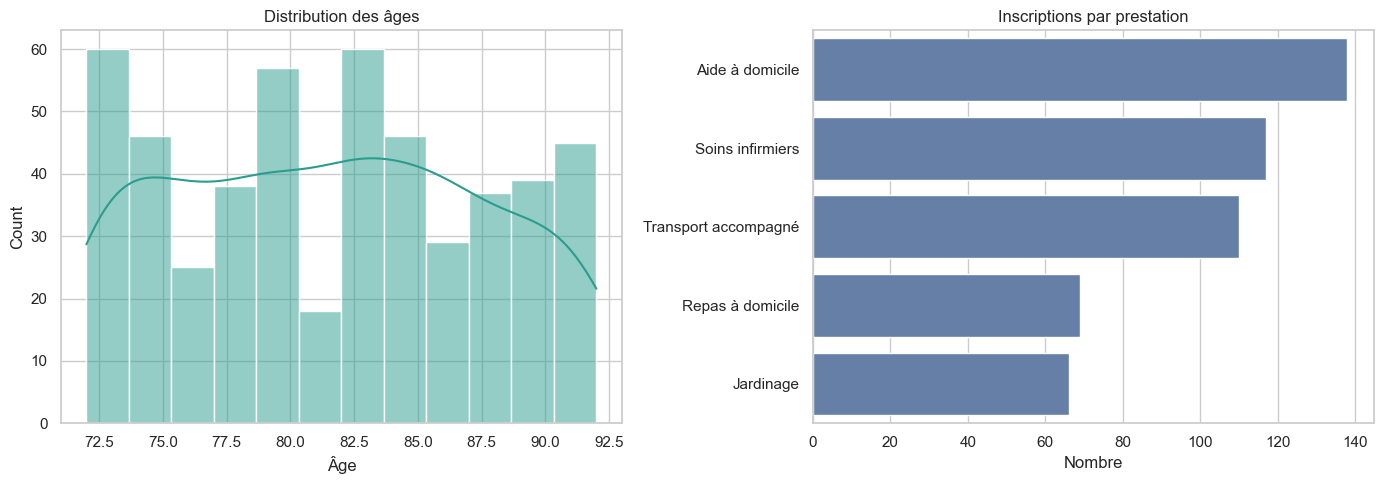

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["age"], bins=12, kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Distribution des âges")
axes[0].set_xlabel("Âge")

cat_counts = df["category"].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[1], color="#5b7db1")
axes[1].set_title("Inscriptions par prestation")
axes[1].set_xlabel("Nombre")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## KPI prestations

In [25]:
inscriptions_total = len(df)
clients_uniques = df["id_user"].nunique()
reinscriptions = df.groupby("id_user").size().gt(1).sum()
taux_reinscription = reinscriptions / clients_uniques if clients_uniques else 0

success_status = ["completed", "accepted", "paid", "validated"]
df["is_success"] = df["status"].str.lower().isin(success_status)

dashboard_global = pd.DataFrame([
    {"KPI": "Inscriptions totales", "Valeur": int(inscriptions_total)},
    {"KPI": "Clients uniques", "Valeur": int(clients_uniques)},
    {"KPI": "Clients réinscrits", "Valeur": int(reinscriptions)},
    {"KPI": "Taux de réinscription", "Valeur": round(float(taux_reinscription), 3)}
])

dashboard_global

,KPI,Valeur
0,Inscriptions totales,500.0
1,Clients uniques,40.0
2,Clients réinscrits,40.0
3,Taux de réinscription,1.0


,category,inscriptions,clients_uniques,succes,taux_succes
0,Aide à domicile,138,38,86,0.623
3,Soins infirmiers,117,36,73,0.624
4,Transport accompagné,110,37,69,0.627
2,Repas à domicile,69,32,45,0.652
1,Jardinage,66,30,36,0.545


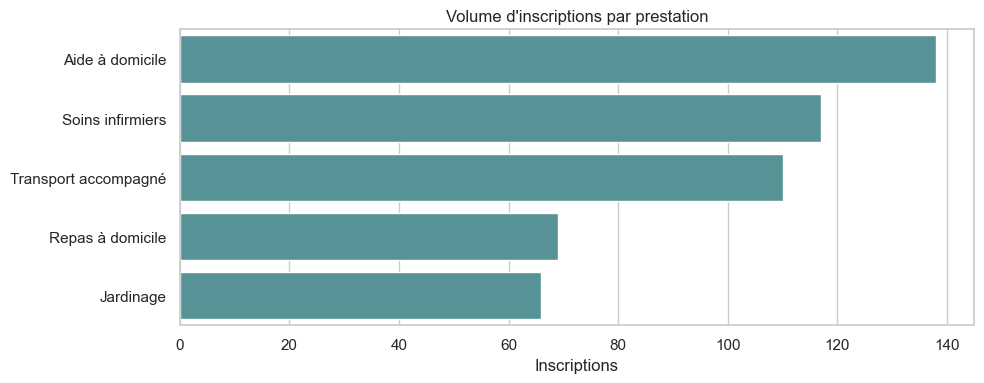

In [26]:
success_status = ["completed", "accepted", "paid", "validated"]
df["is_success"] = df["status"].str.lower().isin(success_status)

perf_category = df.groupby("category").agg(
    inscriptions=("id_user", "count"),
    clients_uniques=("id_user", pd.Series.nunique),
    succes=("is_success", "sum"),
).reset_index()
perf_category["taux_succes"] = (perf_category["succes"] / perf_category["inscriptions"]).round(3)
perf_category = perf_category.sort_values("inscriptions", ascending=False)

display(perf_category)

plt.figure(figsize=(10, 4))
sns.barplot(data=perf_category, x="inscriptions", y="category", color="#4c9da0")
plt.title("Volume d'inscriptions par prestation")
plt.xlabel("Inscriptions")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Modèle ML (simple)

## Export modèle et métriques

In [27]:
df_ml = df.sort_values(["id_user", "created_at"]).copy()

user_features = df_ml.groupby("id_user").agg(
    age_moyen=("age", "mean"),
    mobilite=("mobility", lambda x: x.mode().iloc[0] if not x.mode().empty else "N/A"),
    ville=("city", lambda x: x.mode().iloc[0] if not x.mode().empty else "N/A"),
    nb_interactions=("category", "count"),
    nb_categories_diff=("category", pd.Series.nunique),
    taux_succes_user=("is_success", "mean")
)

target = df_ml.groupby("id_user")["category"].agg(lambda x: x.value_counts().idxmax()).rename("target_category")

dataset_ml = user_features.join(target, how="inner").dropna().copy()

X = dataset_ml.drop(columns=["target_category"])
y = dataset_ml["target_category"]

cat_cols = ["mobilite", "ville"]
num_cols = ["age_moyen", "nb_interactions", "nb_categories_diff", "taux_succes_user"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42))
    ]
)

class_counts = y.value_counts()
can_stratify = class_counts.min() >= 2 and y.nunique() > 1
stratify_target = y if can_stratify else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=stratify_target
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 pondéré: {f1:.4f}")
print(f"Stratification utilisée: {can_stratify}")
pd.DataFrame(report).transpose().round(4)

Accuracy: 0.4000
F1 pondéré: 0.4100
Stratification utilisée: False


,precision,recall,f1-score,support
Aide à domicile,0.6667,0.4000,0.50,5.0
Jardinage,0.0000,0.0000,0.00,1.0
Repas à domicile,0.0000,0.0000,0.00,0.0
Soins infirmiers,0.2500,1.0000,0.40,1.0
Transport accompagné,0.5000,0.3333,0.40,3.0
accuracy,0.4000,0.4000,0.40,0.4
macro avg,0.2833,0.3467,0.26,10.0
weighted avg,0.5083,0.4000,0.41,10.0


In [28]:
out_dir = Path.cwd() / "ia_output"
if not out_dir.exists():
    out_dir = Path("..") / "ia_output"
out_dir.mkdir(parents=True, exist_ok=True)

model_path = out_dir / "model_prestation_classifier.joblib"
metrics_path = out_dir / "metrics_module1_ia.txt"

joblib.dump(model, model_path)

metrics_payload = {
    "accuracy": float(accuracy),
    "f1_weighted": float(f1),
    "n_clients": int(dataset_ml.shape[0]),
    "classes": sorted(y.unique().tolist()),
}

with metrics_path.open("w", encoding="utf-8") as f:
    f.write(json.dumps(metrics_payload, ensure_ascii=False, indent=2))

print(f"Modèle sauvegardé: {model_path}")
print(f"Métriques sauvegardées: {metrics_path}")

exemple_client = pd.DataFrame([
    {
        "age_moyen": 82,
        "mobilite": "Réduite",
        "ville": "Paris",
        "nb_interactions": 6,
        "nb_categories_diff": 2,
        "taux_succes_user": 0.66,
    }
])

prediction = model.predict(exemple_client)[0]
proba = model.predict_proba(exemple_client).max()
print(f"Prédiction prestation: {prediction} (confiance={proba:.2%})")

Modèle sauvegardé: c:\MAMP\htdocs\thib\Silver-Happy\ia_output\model_prestation_classifier.joblib
Métriques sauvegardées: c:\MAMP\htdocs\thib\Silver-Happy\ia_output\metrics_module1_ia.txt
Prédiction prestation: Aide à domicile (confiance=36.00%)
